<a href="https://colab.research.google.com/github/nandinireddimalli-glitch/Unsupervised_Learning_Model_Evaluation/blob/main/Unsupervised_Learning_Model_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unsupervised Learning & Model Evaluation

## Project Overview

This project demonstrates important machine learning concepts including unsupervised learning, clustering, dimensionality reduction, classification, model evaluation, cross-validation, and hyperparameter tuning.

### Objectives

- Perform K-Means clustering
- Determine the optimal number of clusters using the Elbow Method
- Evaluate clusters using the Silhouette Score
- Perform Hierarchical Clustering
- Visualize clusters using a dendrogram
- Apply PCA for dimensionality reduction
- Train a Logistic Regression classification model
- Evaluate the model using a confusion matrix
- Calculate precision, recall, F1-score, and ROC-AUC
- Perform cross-validation
- Apply hyperparameter tuning using GridSearchCV
- Compare the original and tuned models

### Technologies

- Python
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- SciPy
- Google Colab


In [1]:

# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Project setup completed!")


NumPy version: 2.1.3
Pandas version: 2.2.3
Project setup completed!


In [4]:

# Create a synthetic customer dataset

from sklearn.datasets import make_blobs

X, y_true = make_blobs(
    n_samples=300,
    centers=4,
    n_features=2,
    cluster_std=1.2,
    random_state=42
)

# Convert into a DataFrame
df = pd.DataFrame(X, columns=["Annual_Income", "Spending_Score"])

# Display first five rows
print(df.head())

# Dataset information
print("\nDataset Shape:", df.shape)
print("\nDataset Information:")
print(df.info())

   Annual_Income  Spending_Score
0      -9.389561        6.303710
1      -9.870824        6.862056
2      -1.522144        7.549274
3      -7.140845       -5.561577
4     -11.284077        6.113819

Dataset Shape: (300, 2)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Annual_Income   300 non-null    float64
 1   Spending_Score  300 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB
None


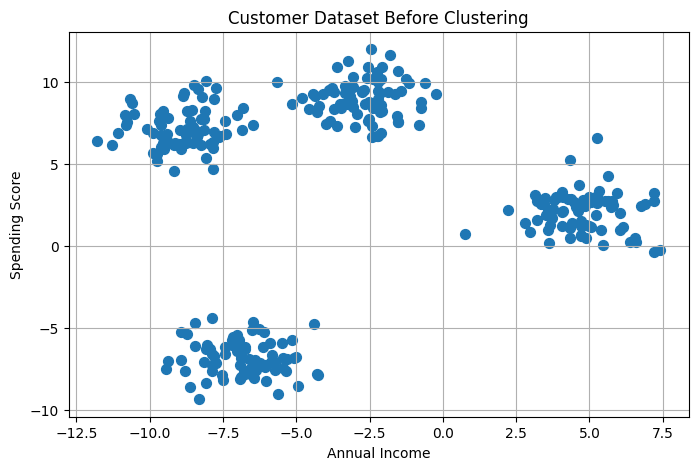

In [5]:

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"],
    s=50
)

plt.title("Customer Dataset Before Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.grid(True)
plt.show()

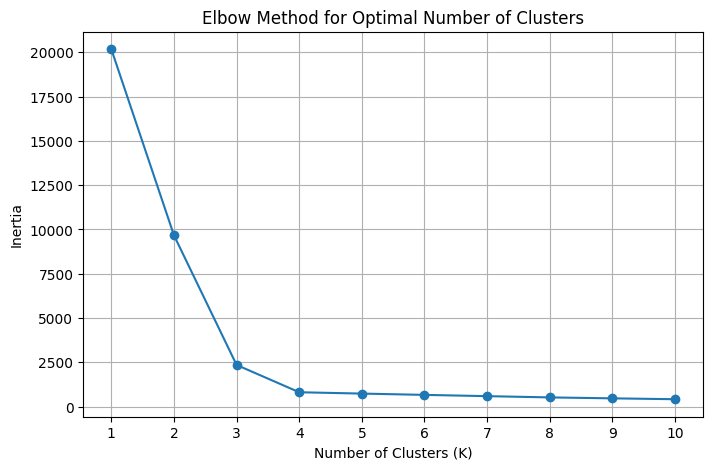

In [6]:
# Elbow Method to find the optimal number of clusters

from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [7]:
# Apply K-Means Clustering

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X)

# Add cluster labels to our DataFrame
df["Cluster"] = cluster_labels

print(df.head())
print("\nCluster Counts:")
print(df["Cluster"].value_counts())

   Annual_Income  Spending_Score  Cluster
0      -9.389561        6.303710        3
1      -9.870824        6.862056        3
2      -1.522144        7.549274        0
3      -7.140845       -5.561577        1
4     -11.284077        6.113819        3

Cluster Counts:
Cluster
0    76
1    75
2    75
3    74
Name: count, dtype: int64


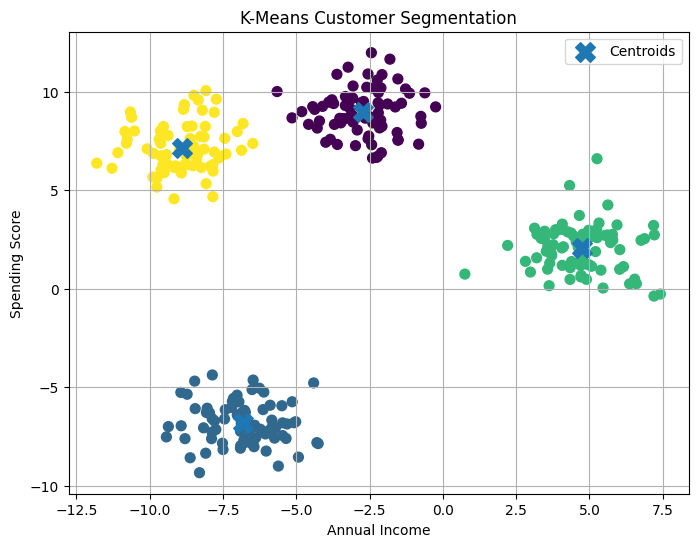

In [8]:
# Visualize K-Means Clusters

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"],
    c=df["Cluster"],
    s=50
)

# Plot cluster centers
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=200,
    label="Centroids"
)

plt.title("K-Means Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Evaluate K-Means using Silhouette Score

from sklearn.metrics import silhouette_score

silhouette = silhouette_score(X, cluster_labels)

print("Silhouette Score:", round(silhouette, 4))

Silhouette Score: 0.7518


In [10]:
# Compare Silhouette Scores for different K values

silhouette_scores = []

for k in range(2, 11):
    kmeans_test = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans_test.fit_predict(X)
    score = silhouette_score(X, labels)

    silhouette_scores.append(score)

# Display the scores
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.5772
K = 3: Silhouette Score = 0.7352
K = 4: Silhouette Score = 0.7518
K = 5: Silhouette Score = 0.6327
K = 6: Silhouette Score = 0.5080
K = 7: Silhouette Score = 0.4122
K = 8: Silhouette Score = 0.3406
K = 9: Silhouette Score = 0.3460
K = 10: Silhouette Score = 0.3649


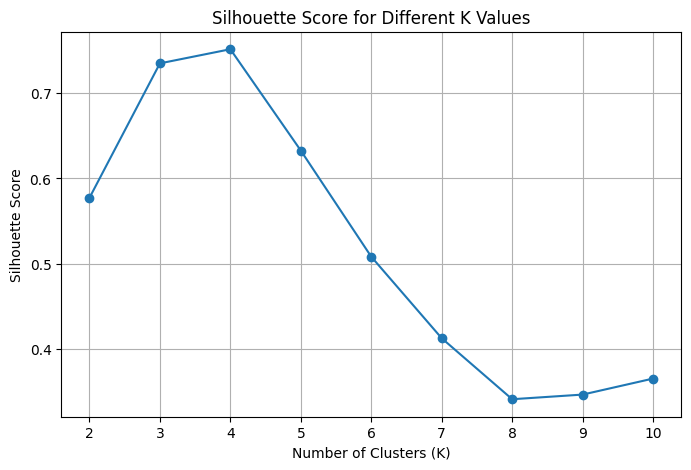

In [11]:
# Plot Silhouette Scores

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

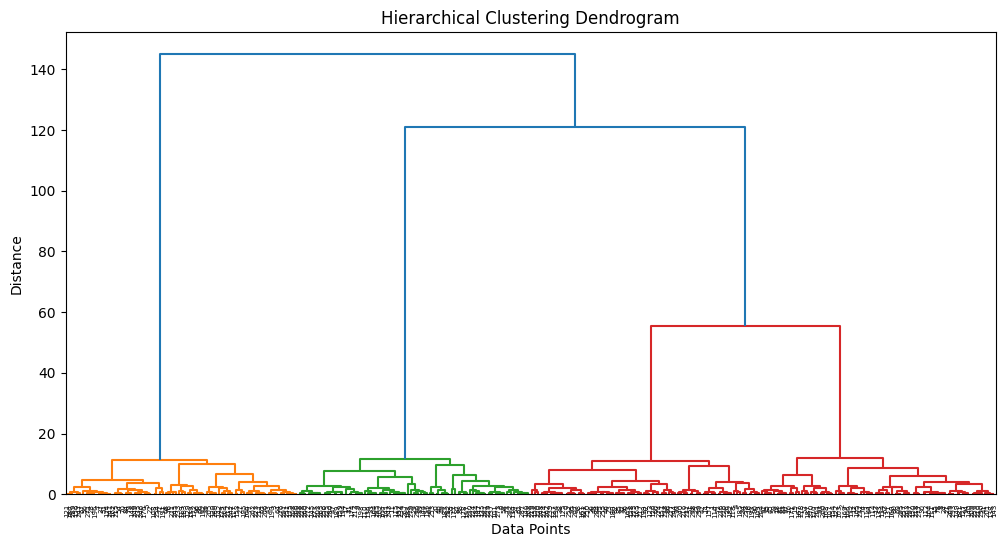

In [12]:
# Hierarchical Clustering - Dendrogram

from scipy.cluster.hierarchy import dendrogram, linkage

# Calculate hierarchical relationships
linked = linkage(X, method="ward")

# Create dendrogram
plt.figure(figsize=(12, 6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [13]:
# Apply Agglomerative Hierarchical Clustering

from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X)

# Add hierarchical cluster labels
df["Hierarchical_Cluster"] = hierarchical_labels

print(df.head())

print("\nHierarchical Cluster Counts:")
print(df["Hierarchical_Cluster"].value_counts())

   Annual_Income  Spending_Score  Cluster  Hierarchical_Cluster
0      -9.389561        6.303710        3                     3
1      -9.870824        6.862056        3                     3
2      -1.522144        7.549274        0                     0
3      -7.140845       -5.561577        1                     1
4     -11.284077        6.113819        3                     3

Hierarchical Cluster Counts:
Hierarchical_Cluster
0    76
1    75
2    75
3    74
Name: count, dtype: int64


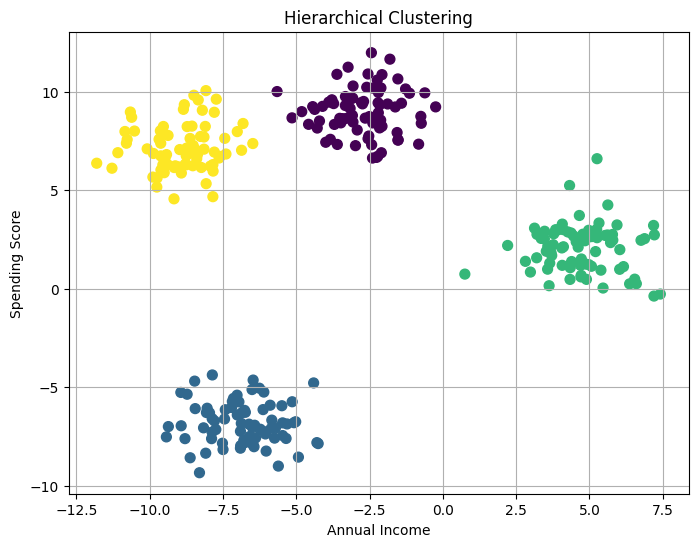

In [14]:
# Visualize Hierarchical Clustering

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"],
    c=df["Hierarchical_Cluster"],
    s=50
)

plt.title("Hierarchical Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.grid(True)
plt.show()

In [15]:
# Evaluate Hierarchical Clustering

hierarchical_score = silhouette_score(
    X,
    hierarchical_labels
)

print(
    "Hierarchical Clustering Silhouette Score:",
    round(hierarchical_score, 4)
)

Hierarchical Clustering Silhouette Score: 0.7518


In [16]:
# Standardize the dataset before PCA

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)

Original shape: (300, 2)
Scaled shape: (300, 2)


In [17]:
# Apply PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA shape:", X_pca.shape)
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:",
      round(pca.explained_variance_ratio_.sum(), 4))

PCA shape: (300, 2)

Explained Variance Ratio:
[0.52840312 0.47159688]

Total Explained Variance: 1.0


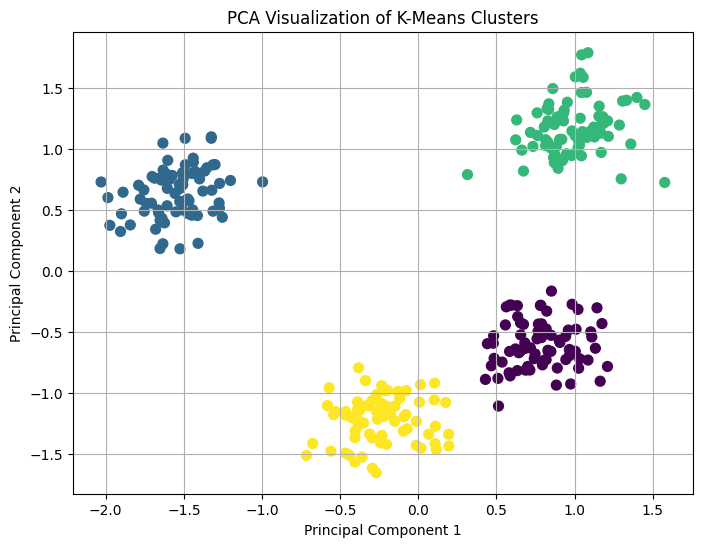

In [18]:
# Visualize PCA components

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    s=50
)

plt.title("PCA Visualization of K-Means Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

In [19]:
# Load classification dataset

from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

X_classification = cancer.data
y_classification = cancer.target

print("Dataset shape:", X_classification.shape)
print("Number of features:", X_classification.shape[1])
print("Number of samples:", X_classification.shape[0])

print("\nTarget names:")
print(cancer.target_names)

Dataset shape: (569, 30)
Number of features: 30
Number of samples: 569

Target names:
['malignant' 'benign']


In [20]:
# Split data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_classification,
    y_classification,
    test_size=0.2,
    random_state=42,
    stratify=y_classification
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [21]:
# Train Logistic Regression model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [22]:
# Make predictions

y_pred = model.predict(X_test)

# Probability of positive class
y_probability = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")
print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!

First 10 predictions:
[0 1 0 1 0 1 1 0 0 0]


Confusion Matrix:
[[39  3]
 [ 1 71]]


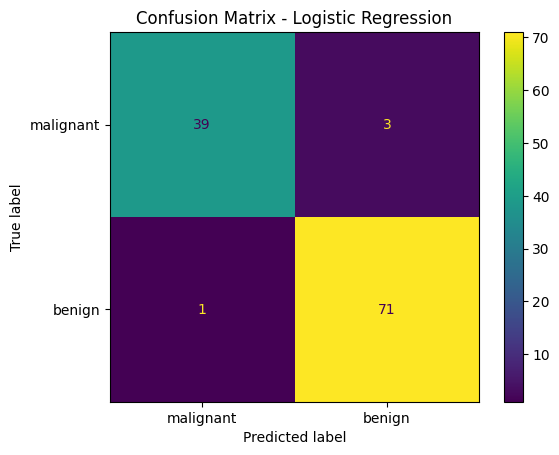

In [23]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Visualize confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=cancer.target_names
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [24]:
# Precision, Recall and F1-Score

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-Score:", round(f1, 4))

Precision: 0.9595
Recall: 0.9861
F1-Score: 0.9726


In [25]:
# ROC-AUC Score

from sklearn.metrics import roc_auc_score, roc_curve

roc_auc = roc_auc_score(y_test, y_probability)

print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 0.9954


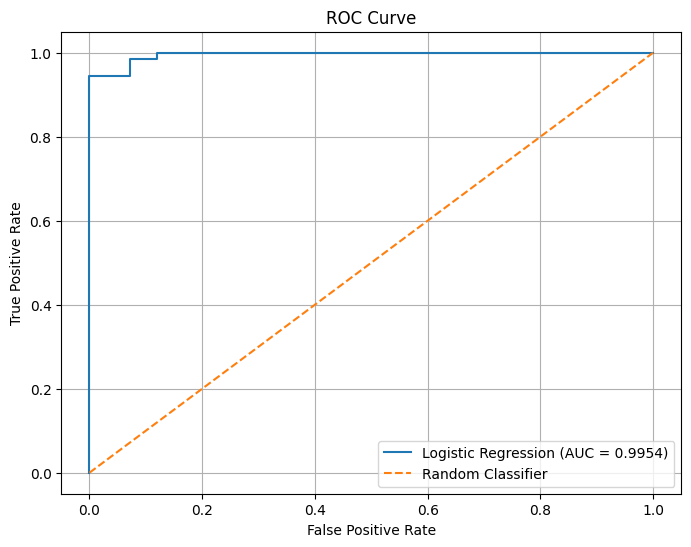

In [26]:
# Plot ROC Curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# Complete Classification Report

from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    target_names=cancer.target_names
)

print(report)

              precision    recall  f1-score   support

   malignant       0.97      0.93      0.95        42
      benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [28]:
# 5-Fold Cross-Validation

from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X_classification,
    y_classification,
    cv=cv,
    scoring="accuracy"
)

print("Cross-Validation Scores:")
print(cv_scores)

print("\nMean CV Accuracy:",
      round(cv_scores.mean(), 4))

print("Standard Deviation:",
      round(cv_scores.std(), 4))

Cross-Validation Scores:
[0.96491228 0.92105263 0.96491228 0.94736842 0.97345133]

Mean CV Accuracy: 0.9543
Standard Deviation: 0.0187


In [29]:
# Hyperparameter Tuning using GridSearchCV

from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=5000),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'C': 10, 'solver': 'liblinear'}

Best Cross-Validation Accuracy:
0.9582


In [30]:
# Evaluate the Tuned Model

best_model = grid_search.best_estimator_

y_tuned_pred = best_model.predict(X_test)
y_tuned_probability = best_model.predict_proba(X_test)[:, 1]

print("Tuned model evaluation completed!")

Tuned model evaluation completed!


In [31]:
# Evaluation metrics for tuned model

tuned_precision = precision_score(y_test, y_tuned_pred)
tuned_recall = recall_score(y_test, y_tuned_pred)
tuned_f1 = f1_score(y_test, y_tuned_pred)
tuned_auc = roc_auc_score(y_test, y_tuned_probability)

print("Precision:", round(tuned_precision, 4))
print("Recall:", round(tuned_recall, 4))
print("F1-Score:", round(tuned_f1, 4))
print("ROC-AUC:", round(tuned_auc, 4))

Precision: 0.9722
Recall: 0.9722
F1-Score: 0.9722
ROC-AUC: 0.9954


In [32]:
# Compare original and tuned models

comparison = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Original Model": [
        precision,
        recall,
        f1,
        roc_auc
    ],
    "Tuned Model": [
        tuned_precision,
        tuned_recall,
        tuned_f1,
        tuned_auc
    ]
})

print(comparison.round(4))

      Metric  Original Model  Tuned Model
0  Precision          0.9595       0.9722
1     Recall          0.9861       0.9722
2   F1-Score          0.9726       0.9722
3    ROC-AUC          0.9954       0.9954


In [33]:
# Final Model Evaluation Summary

final_results = pd.DataFrame({
    "Metric": [
        "K-Means Silhouette Score",
        "Hierarchical Silhouette Score",
        "Cross-Validation Accuracy",
        "Original Precision",
        "Original Recall",
        "Original F1-Score",
        "Original ROC-AUC",
        "Tuned Precision",
        "Tuned Recall",
        "Tuned F1-Score",
        "Tuned ROC-AUC"
    ],
    "Score": [
        silhouette,
        hierarchical_score,
        cv_scores.mean(),
        precision,
        recall,
        f1,
        roc_auc,
        tuned_precision,
        tuned_recall,
        tuned_f1,
        tuned_auc
    ]
})

final_results["Score"] = final_results["Score"].round(4)

print(final_results)

                           Metric   Score
0        K-Means Silhouette Score  0.7518
1   Hierarchical Silhouette Score  0.7518
2       Cross-Validation Accuracy  0.9543
3              Original Precision  0.9595
4                 Original Recall  0.9861
5               Original F1-Score  0.9726
6                Original ROC-AUC  0.9954
7                 Tuned Precision  0.9722
8                    Tuned Recall  0.9722
9                  Tuned F1-Score  0.9722
10                  Tuned ROC-AUC  0.9954


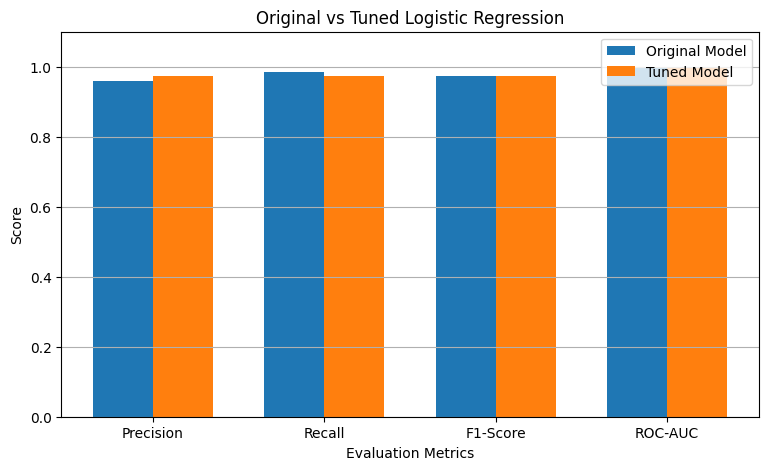

In [34]:
# Compare Original and Tuned Model

metrics = ["Precision", "Recall", "F1-Score", "ROC-AUC"]

original_scores = [
    precision,
    recall,
    f1,
    roc_auc
]

tuned_scores = [
    tuned_precision,
    tuned_recall,
    tuned_f1,
    tuned_auc
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    original_scores,
    width,
    label="Original Model"
)

plt.bar(
    x + width / 2,
    tuned_scores,
    width,
    label="Tuned Model"
)

plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("Original vs Tuned Logistic Regression")
plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis="y")

plt.show()

# Conclusion

This project explored both unsupervised learning and supervised model evaluation techniques.

K-Means clustering was used to divide the dataset into meaningful groups, while the Elbow Method and Silhouette Score were used to evaluate the clustering quality. Hierarchical Clustering was also implemented and visualized using a dendrogram.

Principal Component Analysis (PCA) was used as a dimensionality reduction technique to transform the data into principal components for easier visualization.

For supervised learning, Logistic Regression was trained and evaluated using a train-test split and 5-fold cross-validation. The model was evaluated using a confusion matrix, precision, recall, F1-score, and ROC-AUC.

Finally, GridSearchCV was used for hyperparameter tuning. The original and tuned models were compared to understand the effect of parameter optimization on model performance.

Overall, this project demonstrates the complete machine learning workflow from clustering and dimensionality reduction to model evaluation and hyperparameter optimization.

In [35]:
# Final Results for Project Report

print("=" * 60)
print("UNSUPERVISED LEARNING & MODEL EVALUATION")
print("=" * 60)

print("\nCLUSTERING RESULTS")
print("-" * 60)
print("K-Means Silhouette Score       :", round(silhouette, 4))
print("Hierarchical Silhouette Score :", round(hierarchical_score, 4))

print("\nCROSS-VALIDATION")
print("-" * 60)
print("Mean CV Accuracy              :", round(cv_scores.mean(), 4))
print("CV Standard Deviation         :", round(cv_scores.std(), 4))

print("\nORIGINAL MODEL")
print("-" * 60)
print("Precision                     :", round(precision, 4))
print("Recall                        :", round(recall, 4))
print("F1-Score                      :", round(f1, 4))
print("ROC-AUC                       :", round(roc_auc, 4))

print("\nBEST HYPERPARAMETERS")
print("-" * 60)
print(grid_search.best_params_)

print("\nTUNED MODEL")
print("-" * 60)
print("Precision                     :", round(tuned_precision, 4))
print("Recall                        :", round(tuned_recall, 4))
print("F1-Score                      :", round(tuned_f1, 4))
print("ROC-AUC                       :", round(tuned_auc, 4))

print("=" * 60)

UNSUPERVISED LEARNING & MODEL EVALUATION

CLUSTERING RESULTS
------------------------------------------------------------
K-Means Silhouette Score       : 0.7518
Hierarchical Silhouette Score : 0.7518

CROSS-VALIDATION
------------------------------------------------------------
Mean CV Accuracy              : 0.9543
CV Standard Deviation         : 0.0187

ORIGINAL MODEL
------------------------------------------------------------
Precision                     : 0.9595
Recall                        : 0.9861
F1-Score                      : 0.9726
ROC-AUC                       : 0.9954

BEST HYPERPARAMETERS
------------------------------------------------------------
{'C': 10, 'solver': 'liblinear'}

TUNED MODEL
------------------------------------------------------------
Precision                     : 0.9722
Recall                        : 0.9722
F1-Score                      : 0.9722
ROC-AUC                       : 0.9954
